# テーマ3 回帰分析

## 目的
- 回帰が「入力から連続値を予測する問題」であることを理解する
- California Housing データで、特徴量と住宅価格の関係を散布図と相関係数で確認する
- train/test 分割を使い、未知データでモデルを評価する
- MAE、RMSE、予測値と実測値の散布図から結果を解釈する

## 今日の成果物
- 価格と関係がありそうな特徴量を、グラフと相関係数から1つ挙げる
- 回帰モデルの誤差を表で確認する
- 予測値と実測値の図から、モデルの当てはまりを短く説明する

## 注意
- California Housing は初回にダウンロードが必要な場合があります
- セルは上から順に実行してください


## 回帰の基本

回帰は、入力データから連続値を予測する問題です。例えば、住宅の情報から価格を予測する場合、入力 $X$ と目的変数 $y$ の関係をモデルで近似します。

線形回帰では、予測値 $\hat{y}$ を次のように表します。

$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_px_p + b
$$

ここで、$x_1, x_2, \ldots, x_p$ は特徴量、$w_1, w_2, \ldots, w_p$ は重み、$b$ は切片です。モデルは、予測値と実測値のずれが小さくなるように重みを学習します。


### Step 0: ライブラリを読み込む
回帰分析で使うライブラリを準備します。線形回帰、決定木、ランダムフォレストを同じ条件で比較できるようにします。


In [22]:
# ===== Step 0: ライブラリ読み込み =====
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']

plt.style.use('seaborn-v0_8')

### Step 1: データを読み込む
California Housing データを読み込み、回帰の目的変数を確認します。最初にデータの形と先頭行を見て全体像をつかみます。


In [ ]:
# ===== Step 1: データ読み込み =====
# 初回実行時は、California Housing データのダウンロードが必要です。
# SSL エラーが出る場合は、Python や証明書のセットアップを確認してください。
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
target_column = 'MedHouseVal'

print('行数, 列数 =', df.shape)
display(df.head())
display(df.describe())


### Step 2: 散布図で関係を見る
説明変数と目的変数の関係を散布図で確認します。「どの変数が効いていそうか」「外れた値はあるか」「直線的な関係に見えるか」に注目してください。


#### 観察ポイント

散布図を見たら、次の問いに答えてください。

1. 点は右上がり、右下がり、ばらばらのどれに近いですか。
2. 極端に外れた点はありますか。
3. 直線だけで説明できそうですか。
4. 価格が上限で止まっているような不自然な形はありますか。

モデルを作る前の観察は、あとで誤差や失敗例を解釈する助けになります。


/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25955 (\N{CJK UNIFIED IDEOGRAPH-6563}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22259 (\N{CJK UNIFIED IDEOGRAPH-56F3}) missing from font(s) Arial.
  fig.canvas.

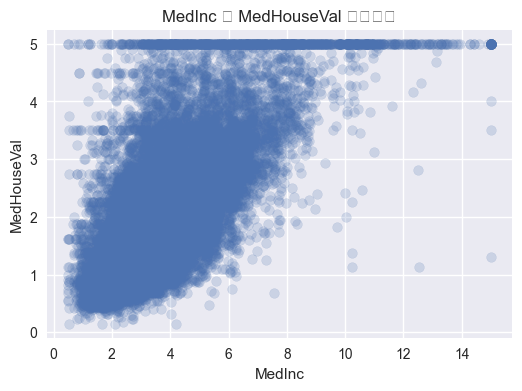

In [24]:
# ===== Step 2: 散布図で関係を見る =====
# TODO: x_col を別の特徴量に変えて試す
x_col = 'MedInc'
y_col = target_column

plt.figure(figsize=(6, 4))
plt.scatter(df[x_col], df[y_col], alpha=0.2)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'{x_col} と {y_col} の散布図')
plt.show()


### Step 3: 相関係数で関係の強さを見る
回帰では、目的変数と関係がありそうな特徴量を探すことが重要です。散布図で見た関係を、相関係数でも確認します。

相関係数は、2つの変数がどの程度一緒に動くかを表す数値です。

$$
r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}}
$$

値の目安は次の通りです。

- $r \simeq 1$: 強い正の相関
- $r \simeq -1$: 強い負の相関
- $r \simeq 0$: 直線的な関係は弱い

ただし、相関があることは「原因である」ことを意味しません。相関と因果は区別して考えます。


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  fig.canvas.

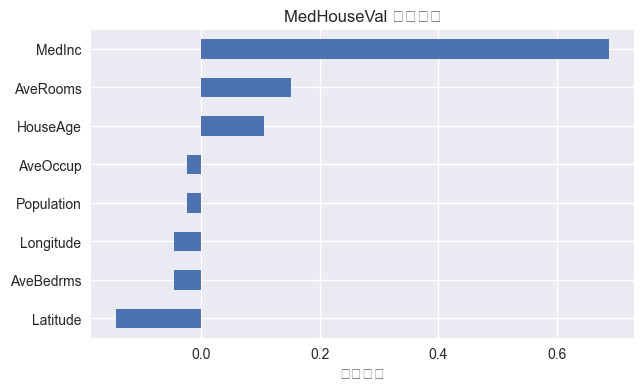

In [25]:
# ===== Step 3: 目的変数との相関を確認する =====
# TODO: 目的変数 MedHouseVal と関係が強そうな特徴量を確認する
corr_with_target = df.corr(numeric_only=True)[target_column].sort_values(ascending=False)
display(corr_with_target)

plt.figure(figsize=(7, 4))
corr_with_target.drop(target_column).sort_values().plot(kind='barh')
plt.xlabel('相関係数')
plt.title(f'{target_column} との相関')
plt.show()


,MedInc,AveRooms,HouseAge,AveOccup,MedHouseVal
MedInc,1.000000,0.326895,-0.119034,0.018766,0.688075
AveRooms,0.326895,1.000000,-0.153277,-0.004852,0.151948
HouseAge,-0.119034,-0.153277,1.000000,0.013191,0.105623
AveOccup,0.018766,-0.004852,0.013191,1.000000,-0.023737
MedHouseVal,0.688075,0.151948,0.105623,-0.023737,1.000000


/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/1303226890.py:13: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/1303226890.py:13: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/1303226890.py:13: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/1303226890.py:13: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/1303226890.py:13: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/i

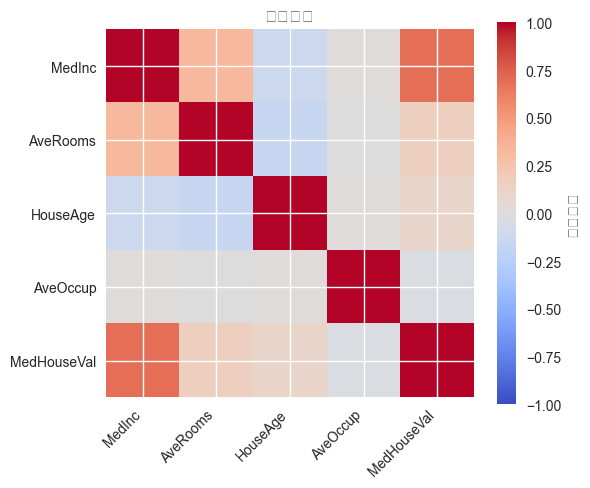

In [26]:
# ===== 追加演習: 相関行列を可視化する =====
# TODO: feature_columns_for_corr を変えて、見たい特徴量を選ぶ
feature_columns_for_corr = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', target_column]
corr_matrix = df[feature_columns_for_corr].corr(numeric_only=True)
display(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='相関係数')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('相関行列')
plt.tight_layout()
plt.show()


### Step 4: 学習用とテスト用に分ける
モデルが学習に使ったデータだけに合っているのか、未知データでも使えるのかを分けて確認するため、train と test に分割します。


#### 解説: train/test 分割

同じデータで学習と評価を行うと、モデルが「覚えただけ」でも良い点数に見えてしまいます。そこで、データを分けます。

- train: モデルが学習に使うデータ
- test: 学習には使わず、最後に評価するデータ

この考え方は、未知のデータに対してどれくらい通用するかを確認するために重要です。


#### 解説: MAE と RMSE

予測値を $\hat{y}_i$、実測値を $y_i$ とすると、誤差は $y_i - \hat{y}_i$ です。

MAE は、誤差の絶対値の平均です。

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

RMSE は、誤差を2乗して平均し、最後に平方根を取ります。

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

RMSE は大きな誤差をより強く反映します。MAE と RMSE のどちらも、値が小さいほど予測と実測のずれが小さいと考えます。


In [27]:
# ===== 追加演習: 誤差を手計算のイメージで確認する =====
example_actual = pd.Series([3.0, 4.0, 5.0])
example_pred = pd.Series([2.5, 4.5, 4.0])
example_error = example_actual - example_pred

print('誤差:', example_error.tolist())
print('絶対誤差:', example_error.abs().tolist())
print('MAE:', example_error.abs().mean())
print('RMSE:', (example_error.pow(2).mean()) ** 0.5)


誤差: [0.5, -0.5, 1.0]
絶対誤差: [0.5, 0.5, 1.0]
MAE: 0.6666666666666666
RMSE: 0.7071067811865476


In [28]:
# ===== Step 4: 学習データとテストデータを作る =====
feature_columns = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']  # TODO: 必要に応じて変更する
X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape =', X_train.shape)
print('X_test shape =', X_test.shape)


X_train shape = (16512, 4)
X_test shape = (4128, 4)


### Step 5: 複数の回帰モデルを比較する
線形回帰、決定木、ランダムフォレストを同じデータで学習し、MAE と RMSE を比べます。誤差は小さいほど予測と実測のずれが小さいことを表します。


In [29]:
# ===== Step 5: モデル比較 =====
models = {
    'linear_regression': LinearRegression(),
    'decision_tree': DecisionTreeRegressor(random_state=42, max_depth=5),
    'random_forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=8),
}

results = []
predictions_by_model = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions_by_model[model_name] = preds
    results.append({
        'model': model_name,
        'mae': mean_absolute_error(y_test, preds),
        'rmse': root_mean_squared_error(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values('rmse')
display(results_df)

/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,model,mae,rmse
2,random_forest,0.475614,0.669974
1,decision_tree,0.530432,0.732053
0,linear_regression,0.602548,0.810834


### Step 6: 予測値と実測値を可視化する
選んだモデルの予測値と実測値を散布図で比べます。理想的には、点が赤い対角線の近くに集まります。


### Step 6.1: モデル比較を可視化する
各モデルの MAE と RMSE をグラフで比較します。表だけでなく、視覚的に違いを確認すると理解が深まります。

/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/713651066.py:16: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/713651066.py:16: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/713651066.py:16: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/713651066.py:16: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/713651066.py:16: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) Arial.
  plt.tight_layout()
/Users/k-z/.jupyter/lib/python3.13/site-packages/IPython/core/pylabtools.py:170

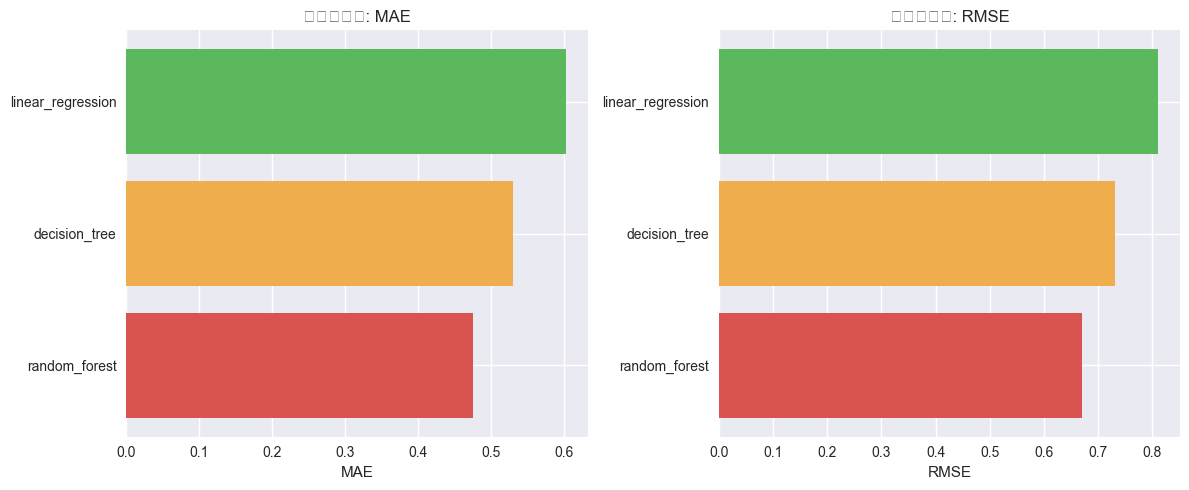

In [19]:
# ===== Step 6.1: モデル比較バーチャート =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE の横棒グラフ
results_sorted_mae = results_df.sort_values('mae')
axes[0].barh(results_sorted_mae['model'], results_sorted_mae['mae'], color=['#D9534F', '#F0AD4E', '#5CB85C'])
axes[0].set_xlabel('MAE')
axes[0].set_title('モデル比較: MAE')

# RMSE の横棒グラフ
results_sorted_rmse = results_df.sort_values('rmse')
axes[1].barh(results_sorted_rmse['model'], results_sorted_rmse['rmse'], color=['#D9534F', '#F0AD4E', '#5CB85C'])
axes[1].set_xlabel('RMSE')
axes[1].set_title('モデル比較: RMSE')

plt.tight_layout()
plt.show()

### Step 6.2: 学習曲線（max_depth の変化）
決定木の max_depth を変えて、モデルの複雑さと誤差の関係を見ます。浅すぎると未学習、深すぎると過学習になりやすいことを確認します。

In [ ]:
# ===== Step 6.2: max_depth と誤差の関係 =====
# TODO: 決定木の深さを変えると、train/test の誤差がどう変わるか確認する
depth_values = range(1, 16)
depth_results = []

for depth in depth_values:
    tree = DecisionTreeRegressor(random_state=42, max_depth=depth)
    tree.fit(X_train, y_train)
    train_preds = tree.predict(X_train)
    test_preds = tree.predict(X_test)
    depth_results.append({
        'max_depth': depth,
        'train_rmse': root_mean_squared_error(y_train, train_preds),
        'test_rmse': root_mean_squared_error(y_test, test_preds),
    })

depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df.head())

plt.figure(figsize=(7, 4))
plt.plot(depth_results_df['max_depth'], depth_results_df['train_rmse'], marker='o', label='train')
plt.plot(depth_results_df['max_depth'], depth_results_df['test_rmse'], marker='o', label='test')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('決定木の深さとRMSE')
plt.legend()
plt.grid(True)
plt.show()


### Step 6.3: 残差（予測誤差）を確認する
残差は「実測値 − 予測値」です。残差がランダムにばらついていればモデルは適切ですが、傾向が見えると「どこを間違えやすいか」が分かります。

- 正の残差: 実測値 > 予測値（過小評価）
- 負の残差: 実測値 < 予測値（過大評価）

/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/183278305.py:24: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/183278305.py:24: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/183278305.py:24: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/183278305.py:24: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_87859/183278305.py:24: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipyker

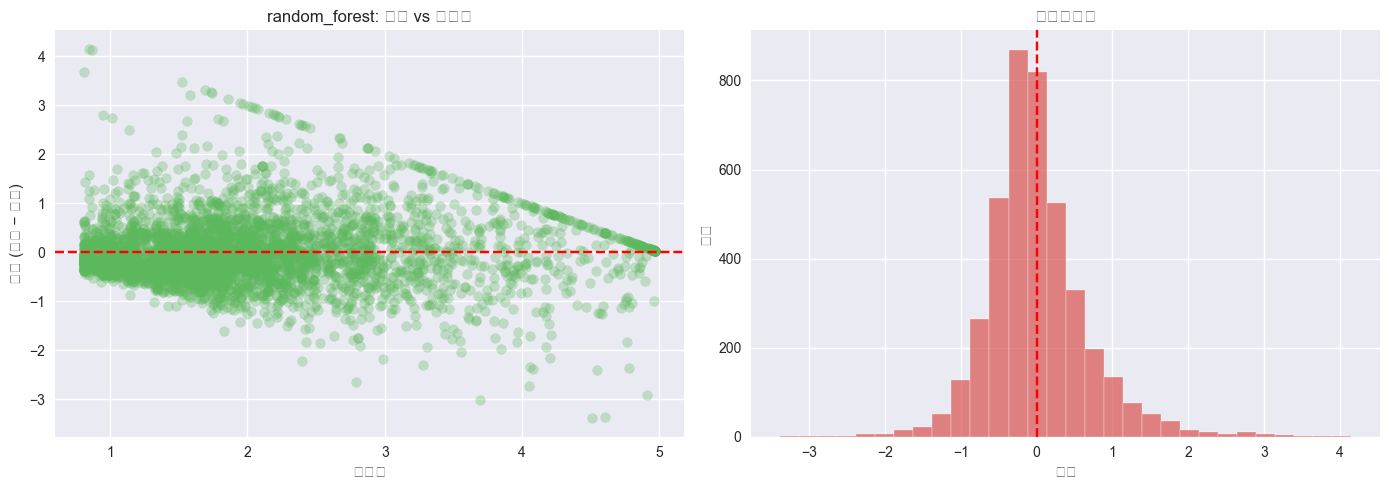

In [20]:
# ===== Step 6.3: 残差のプロット =====
selected_model = results_df.iloc[0]['model']
selected_predictions = predictions_by_model[selected_model]
residuals = y_test.values - selected_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 残差散布図（実測値 vs 残差）
axes[0].scatter(selected_predictions, residuals, alpha=0.3, color='#5CB85C')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('予測値')
axes[0].set_ylabel('残差 (実測 − 予測)')
axes[0].set_title(f'{selected_model}: 残差 vs 予測値')
axes[0].grid(True)

# 残差のヒストグラム
axes[1].hist(residuals, bins=30, color='#D9534F', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('残差')
axes[1].set_ylabel('件数')
axes[1].set_title('残差の分布')
axes[1].grid(True)

plt.tight_layout()
plt.show()

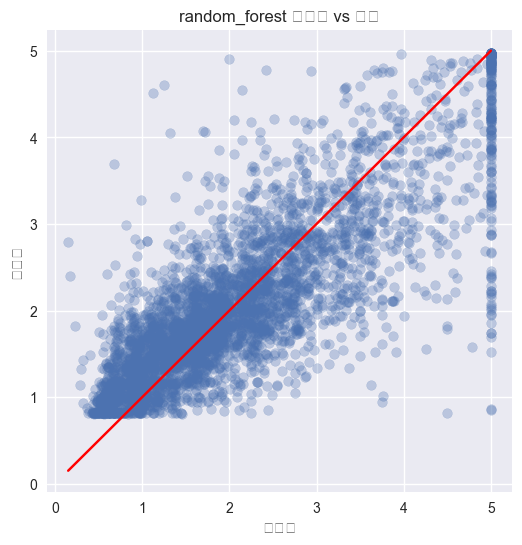

In [21]:
# ===== Step 6: 予測値と実測値の可視化 =====
# TODO: selected_model を変えて比較する
selected_model = results_df.iloc[0]['model']
selected_predictions = predictions_by_model[selected_model]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, selected_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel('実測値')
plt.ylabel('予測値')
plt.title(f'{selected_model} の予測 vs 実測')
plt.show()


### Step 6.4: 交差検証で評価のぶれを見る
train/test 分割は1回の分け方に依存します。発展として、k-fold 交差検証で評価の平均的な傾向も確認してみます。

In [ ]:
cv_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=8)
cv_scores = cross_val_score(
    cv_model,
    X[feature_columns],
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
)

cv_rmse = -cv_scores
print('各foldのRMSE:', cv_rmse.round(3).tolist())
print('平均RMSE:', round(cv_rmse.mean(), 3))
print('標準偏差:', round(cv_rmse.std(), 3))

## 発展演習

時間があれば、次を試してください。

1. `feature_columns` に `Latitude` や `Longitude` を追加する。
2. `DecisionTreeRegressor` の `max_depth` を変える。
3. `RandomForestRegressor` の `n_estimators` を変える。
4. RMSE が小さくなったとき、散布図の見え方も良くなっているか確認する。

数値が良くなっただけで終わらず、図と合わせて説明してください。


## 振り返り
- 目的変数との相関が強かった特徴量はどれですか。散布図の見え方と一致していましたか。
- `feature_columns` を増やしたり減らしたりすると、誤差はどう変わりましたか。
- どのモデルの RMSE が最も小さかったですか。
- 予測値と実測値の散布図から、どのような失敗や限界が見えましたか。
- train/test 分割を行う目的を、自分の言葉で説明してください。


## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: 特徴量選択の影響 (簡単)

1. `feature_columns` を `[ 'MedInc' ]` のみ（1つだけ）にしてモデルを再学習させてください。
2. 複数の特徴量を使った場合と比べて、RMSEはどう変わりましたか。
3. 特徴量を1つ増やすと、誤差はどのように変化しましたか。

```python
# ここにコードを書いてください
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 特徴量を1つだけ使う
feature_columns_single = ['MedInc']
X_single = df[feature_columns_single]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = root_mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)
print(f"RMSE (1特徴量): {rmse:.2f}")
print(f"MAE (1特徴量): {mae:.2f}")
```

### 演習2: モデル比較 (簡単)

1. 線形回帰とランダムフォレストの予測結果を比較してください。
2. どちらのモデルがテストデータで良い結果を出しましたか。
3. 訓練データでの性能とテストデータでの性能に差はありましたか。

```python
# ここにコードを書いてください
from sklearn.ensemble import RandomForestRegressor

X = df[feature_columns]
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 線形回帰
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_rmse = root_mean_squared_error(y_test, lr.predict(X_test))

# ランダムフォレスト
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_rmse = root_mean_squared_error(y_test, rf.predict(X_test))

print(f"線形回帰 RMSE: {lr_rmse:.2f}")
print(f"ランダムフォレスト RMSE: {rf_rmse:.2f}")
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **回帰分析とは** (200字程度)
   - 回帰分析がどのような問題を解くものか、自分の言葉で説明してください。また、現実世界で回帰が使われる例を1つ挙げてください。

2. **評価指標の理解** (200字程度)
   - RMSEとMAEの違いを説明してください。また、なぜ複数の指標を使うことが大切なのか考えてください。

3. **モデル比較の結果** (300字程度)
   - 演習で比較したモデルのうち、最も良い結果を出したのはどれですか。その理由を、数値（RMSE/MAE）と散布図の両方から説明してください。

4. **過学習について** (200字程度)
   - 「訓練データでは良いが、テストデータではうまくいかない」という状況を自分の言葉で説明してください。なぜこのようなことが起こるのでしょうか。

